In [1]:
### Hayden Gallo
### Bucci Lab
### DySCoMeMo    
### 1/27/26
### Testing how to get MDSINE pickle in sufficient format for utilizing with new scheme for DySCoMeMo 

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import math as m
import seaborn as sns
import pandas as pd
import math
#import mdsine2 as md2
from pathlib import Path
import os
from scipy.stats import truncnorm
import json
from Bio import Entrez
from Bio import SeqIO
import time
import pickle
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
import statsmodels.nonparametric.smoothers_lowess as loess

from scipy.signal import savgol_filter

from tqdm import tqdm
from matplotlib.lines import Line2D
#from whittaker_eilers import WhittakerSmoother

In [2]:
### gLV function with perturbations

def gLV_perturb(t, init_abun, int_matrix, basal_grow, perturbations):

    """gLV model with perturbations incorporated as step functions.
    
    Args:
        t (float): time
        init_abun (array): array of initial abundances for each species
        int_matrix (2D array): interaction matrix between species
        basal_grow (array): array of basal growth rates for each species
        perturbations (array): array of perturbation magnitudes for each species
        
    
    Returns:
        dXdt (array): rate of change of abundances
    """
    # Determine current perturbation state based on time

    if t <= 1.0 or t >= 3.0:
        current_perturb = np.zeros(len(init_abun))
    else:
        current_perturb = perturbations
        print('perturbation')
    
    # Calculate the rate of change of abundances
    dXdt = init_abun * (basal_grow + np.dot(int_matrix, init_abun) + current_perturb)
    
    return dXdt

In [3]:
# Load pkls from the MDSINE2 inference

data_dir = Path('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl')

os.chdir(data_dir)
print(os.getcwd())

/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl


In [4]:
### load in the growth rates
#growth_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/growth/values.tsv', sep = '\t')
### load in interaction matrix
#int_matrix_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/interactions/mean_matrix.tsv', sep = '\t', index_col=0)
### load in self interactions
#self_ints_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/self_interactions/values.tsv', sep = '\t')
### load in perturbations 
#perturbations_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/ABX/values.tsv', sep = '\t')

In [5]:
#### using alternative params 


### load in the growth rates
#growth_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/merged_studies_test_02_10_26/posterior/growth/values.tsv', sep = '\t')
### load in interaction matrix
#int_matrix_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/merged_studies_test_02_10_26/posterior/interactions/median_matrix.tsv', sep = '\t', index_col=0)
### load in self interactions
#self_ints_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/merged_studies_test_02_10_26/posterior/self_interactions/values.tsv', sep = '\t')
#### load in perturbations 
#perturbations_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/merged_studies_test_02_10_26/posterior/ABX/values.tsv', sep = '\t')


In [6]:
perturbations_df

NameError: name 'perturbations_df' is not defined

In [ ]:
growth_rates_mean = growth_df.loc[1:,'median']
growth_rates_mean

1     0.635760
2     0.028309
3     0.311464
4     0.022959
5     0.063892
6     0.424605
7     0.081758
8     0.019926
9     0.044239
10    0.037531
11    0.218921
12    0.015096
13    0.022433
14    0.259302
15    0.034771
Name: median, dtype: float64

In [ ]:
int_matrix_df

,14ac4eaad5b4e2ff3c071832e0fd4229,18673193aa6bf30c6a1e71ac504e04df,320dfd16200daaf2b0503975d4e68fd5,36173253c63ad49abc12361a0b3304eb,391821255f31ef94686927f4fba6fbc3,3936cc515320e9f29d81ffeaa92718e8,3e741fc097143bb6782af5233cb7af98,4cc9a4b9aaa3ee9a5c14cc27551a6844,795b6ba45f502a00b24b212278991c63,7ca7ca8214441730c2437d1f53390cdb,94e30534f622e456a683abe4e60fc214,9cf5cb71450a2aa080ff905f89b0a624,e3147edad1f84fae8bb6fd6f5e7a97b9,e8aae590cf49eb3c80ad7e08f2d3c3c4,eba523a4a554db4ad7e9dcff257bf1c8
14ac4eaad5b4e2ff3c071832e0fd4229,0.000000e+00,0.0,-3.882409e-12,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
18673193aa6bf30c6a1e71ac504e04df,0.000000e+00,0.0,-4.672115e-12,0.0,5.084084e-12,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
320dfd16200daaf2b0503975d4e68fd5,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
36173253c63ad49abc12361a0b3304eb,0.000000e+00,0.0,-1.820332e-12,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
391821255f31ef94686927f4fba6fbc3,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
3936cc515320e9f29d81ffeaa92718e8,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
3e741fc097143bb6782af5233cb7af98,0.000000e+00,0.0,0.000000e+00,0.0,-3.679372e-12,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
4cc9a4b9aaa3ee9a5c14cc27551a6844,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
795b6ba45f502a00b24b212278991c63,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
7ca7ca8214441730c2437d1f53390cdb,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0


In [ ]:
self_ints_df

,Unnamed: 0,name,median,mean,25th percentile,75th percentile
0,mean,Mean parameter for the truncated normal prior ...,4.074055e-12,5.272319e-12,8.193328e-13,6.812741e-12
1,14ac4eaad5b4e2ff3c071832e0fd4229,Bifidobacterium 14ac4eaad5b4e2ff3c071832e0fd42...,2.463099e-11,3.241218e-11,6.731233e-12,4.569706e-11
2,18673193aa6bf30c6a1e71ac504e04df,Jeotgalicoccus 18673193aa6bf30c6a1e71ac504e04d...,6.270262e-12,7.011790e-12,5.333445e-12,8.309996e-12
3,320dfd16200daaf2b0503975d4e68fd5,Lactobacillus Lactobacillus reuteri 320dfd1620...,9.286808e-12,1.109959e-11,7.829129e-12,1.202265e-11
4,36173253c63ad49abc12361a0b3304eb,uncultured uncultured bacterium 36173253c63ad4...,2.254865e-12,5.420288e-12,5.847855e-13,8.769076e-12
5,391821255f31ef94686927f4fba6fbc3,uncultured bacterium uncultured bacterium 3918...,7.574553e-12,7.461549e-12,6.124769e-12,8.788891e-12
6,3936cc515320e9f29d81ffeaa92718e8,[Eubacterium] coprostanoligenes group 3936cc51...,1.836370e-11,2.099076e-11,1.317768e-11,2.401138e-11
7,3e741fc097143bb6782af5233cb7af98,uncultured bacterium uncultured bacterium 3e74...,9.265091e-12,1.253785e-11,5.617517e-12,1.603067e-11
8,4cc9a4b9aaa3ee9a5c14cc27551a6844,Enterococcus 4cc9a4b9aaa3ee9a5c14cc27551a6844 ...,3.987746e-12,5.997587e-12,1.690399e-12,9.217057e-12
9,795b6ba45f502a00b24b212278991c63,Turicibacter uncultured bacterium 795b6ba45f50...,1.673325e-12,2.359016e-12,8.472190e-13,3.123391e-12


In [ ]:
self_ints = self_ints_df.loc[1:,'median']
self_ints = -np.absolute(self_ints)

In [ ]:
for i in range(0, self_ints.shape[0]):
    int_matrix_df.iloc[i,i] = self_ints.iloc[i]


int_matrix_df

,14ac4eaad5b4e2ff3c071832e0fd4229,18673193aa6bf30c6a1e71ac504e04df,320dfd16200daaf2b0503975d4e68fd5,36173253c63ad49abc12361a0b3304eb,391821255f31ef94686927f4fba6fbc3,3936cc515320e9f29d81ffeaa92718e8,3e741fc097143bb6782af5233cb7af98,4cc9a4b9aaa3ee9a5c14cc27551a6844,795b6ba45f502a00b24b212278991c63,7ca7ca8214441730c2437d1f53390cdb,94e30534f622e456a683abe4e60fc214,9cf5cb71450a2aa080ff905f89b0a624,e3147edad1f84fae8bb6fd6f5e7a97b9,e8aae590cf49eb3c80ad7e08f2d3c3c4,eba523a4a554db4ad7e9dcff257bf1c8
14ac4eaad5b4e2ff3c071832e0fd4229,-2.463099e-11,0.000000e+00,-3.882409e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
18673193aa6bf30c6a1e71ac504e04df,0.000000e+00,-6.270262e-12,-4.672115e-12,0.000000e+00,5.084084e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
320dfd16200daaf2b0503975d4e68fd5,0.000000e+00,0.000000e+00,-9.286808e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
36173253c63ad49abc12361a0b3304eb,0.000000e+00,0.000000e+00,-1.820332e-12,-2.254865e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
391821255f31ef94686927f4fba6fbc3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-7.574553e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3936cc515320e9f29d81ffeaa92718e8,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.836370e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3e741fc097143bb6782af5233cb7af98,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.679372e-12,0.000000e+00,-9.265091e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4cc9a4b9aaa3ee9a5c14cc27551a6844,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.987746e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
795b6ba45f502a00b24b212278991c63,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.673325e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7ca7ca8214441730c2437d1f53390cdb,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.604087e-13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [ ]:
perturbations_mean = perturbations_df.loc[:,'mean']
perturbations_mean

0      0.526927
1      6.004266
2      0.801334
3    -22.114906
4      5.268316
5     -0.845906
6    -16.163222
7     -2.730547
8     -4.600229
9    -25.832346
10    -0.184543
11   -17.578733
12   -13.762669
13     0.832295
14     8.963477
Name: mean, dtype: float64

In [23]:
### load in refseq to agora with name mappings 

refseq_to_agora = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/refseq_to_agora_update_07_07_25.csv')
refseq_to_agora

asv_to_agora_dict = dict(zip(refseq_to_agora['ASV_string'], refseq_to_agora['Agora_Name']))
asv_to_agora_dict

{'14ac4eaad5b4e2ff3c071832e0fd4229': 'Bifidobacterium_pseudolongum',
 '18673193aa6bf30c6a1e71ac504e04df': 'Jeotgalicoccus_nanhaiensis',
 '320dfd16200daaf2b0503975d4e68fd5': 'Lactobacillus_reuteri',
 '36173253c63ad49abc12361a0b3304eb': 'Merdibacter_massiliensis',
 '391821255f31ef94686927f4fba6fbc3': 'Duncaniealla_sp',
 '3936cc515320e9f29d81ffeaa92718e8': 'Ruminococcus_bicirculans',
 '3e741fc097143bb6782af5233cb7af98': 'Muribaculum_intestinale',
 '4cc9a4b9aaa3ee9a5c14cc27551a6844': 'Enterococcus_faecalis',
 '795b6ba45f502a00b24b212278991c63': 'Turicibacter_sp',
 '7ca7ca8214441730c2437d1f53390cdb': 'Erysipelotrichaceae_sp',
 '94e30534f622e456a683abe4e60fc214': 'Lactobacillus_murinus',
 '9cf5cb71450a2aa080ff905f89b0a624': 'Bacteroides_caecimuris',
 'e3147edad1f84fae8bb6fd6f5e7a97b9': 'Lactobacillus_intestinalis',
 'e8aae590cf49eb3c80ad7e08f2d3c3c4': 'Lactobacillus_gasseri',
 'eba523a4a554db4ad7e9dcff257bf1c8': 'Staphylococcus_LKG31'}

In [14]:
### Subject to simulate 
subject_to_plot = 1507

In [15]:
output_folder = 'filtering_hourly_resolution'

output_path = '/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/' + output_folder + '/Subject_' + str(subject_to_plot) + '/mean_smoothed.tsv'
MDSINE_output = pd.read_csv(output_path, delimiter='\t', index_col=0)

MDSINE_output_raw = MDSINE_output.copy()

In [16]:
init_abun = MDSINE_output_raw.iloc[:,0].to_numpy()
init_abun

array([8.22426869e+02, 3.59886334e+03, 4.58536810e+09, 2.81104241e+03,
       1.00477346e+09, 2.12047986e+06, 1.75615609e+07, 2.33132008e+03,
       5.53928669e+03, 3.01249529e+09, 7.87025227e+08, 5.64899251e+08,
       2.17359162e+09, 1.81023683e+09, 1.81209624e+04])

In [17]:
MDSINE_output = MDSINE_output.melt(ignore_index=False)
MDSINE_output = MDSINE_output.reset_index()
MDSINE_output.columns = ['species','time', 'count']
MDSINE_output['time'] = MDSINE_output['time'].astype(float)

MDSINE_output

,species,time,count
0,14ac4eaad5b4e2ff3c071832e0fd4229,-3.0,8.224269e+02
1,18673193aa6bf30c6a1e71ac504e04df,-3.0,3.598863e+03
2,320dfd16200daaf2b0503975d4e68fd5,-3.0,4.585368e+09
3,36173253c63ad49abc12361a0b3304eb,-3.0,2.811042e+03
4,391821255f31ef94686927f4fba6fbc3,-3.0,1.004773e+09
...,...,...,...
6235,94e30534f622e456a683abe4e60fc214,14.0,1.130606e+10
6236,9cf5cb71450a2aa080ff905f89b0a624,14.0,2.106833e+02
6237,e3147edad1f84fae8bb6fd6f5e7a97b9,14.0,4.806426e+08
6238,e8aae590cf49eb3c80ad7e08f2d3c3c4,14.0,2.769648e+02


In [18]:
times = np.linspace(0,17,4160)

perturb_times_df = pd.DataFrame({'time': times})
perturb_times_df['perturb'] = ((perturb_times_df['time'] >= 2.0) & (perturb_times_df['time'] <= 5.0)).astype(int)
perturb_times_df

,time,perturb
0,0.000000,0
1,0.004088,0
2,0.008175,0
3,0.012263,0
4,0.016350,0
...,...,...
4155,16.983650,0
4156,16.987737,0
4157,16.991825,0
4158,16.995912,0


In [ ]:
#### make everything into arrays 

int_array = np.array(int_matrix_df)
basal_grow_array = np.array(growth_rates_mean)
perturb_array = np.array(perturbations_mean)

In [ ]:
args = (int_array, basal_grow_array, perturb_array)

In [7]:
### reload everything in 

growth_array = np.array(pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/median_grow.csv', index_col=0)).reshape(-1)
growth_array

array([0.85315574, 0.28639573, 0.67762913, 0.10760468, 0.41161314,
       0.8168768 , 0.13197057, 0.20803693, 0.46017088, 0.1307683 ,
       0.29185633, 0.05725774, 0.18101538, 0.12213617, 0.29930456])

In [8]:
int_array = np.array(pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/median_interactions.csv', index_col=0))
int_array

array([[-8.47700426e-11, -2.16062410e-10,  0.00000000e+00,
        -1.04854015e-10,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -5.87852273e-12,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -5.37454043e-10,  0.00000000e+00,
        -4.18480078e-10,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -1.96985775e-11,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.55015365e-10, -7.15871688e-11,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.93249275e-10,  0.00000000e+00,
        -2.51827532e-10,  0.00000000e+00,  0.00000000

In [9]:
perturb_array = np.array(pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/median_perturbations_test.csv', index_col=0)).reshape(-1)
#perturb_array = -1.0*np.abs(perturb_array)

In [10]:
args = (int_array, growth_array, perturb_array)

In [19]:
times

array([0.00000000e+00, 4.08752104e-03, 8.17504208e-03, ...,
       1.69918250e+01, 1.69959125e+01, 1.70000000e+01])

In [20]:
sol_odeint = odeint(gLV_perturb, init_abun,times, args = args, tfirst = True)

perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation

In [21]:
sol_odeint_df = pd.DataFrame(sol_odeint, columns = MDSINE_output_raw.index, index = times)
sol_odeint_df = sol_odeint_df.melt(ignore_index=False).reset_index()
sol_odeint_df.columns = ['time','species', 'count']
sol_odeint_df['time'] = sol_odeint_df['time'] - 3.0

In [24]:
species_name_list = []
for species in MDSINE_output_raw.index:
    species_name_list.append(asv_to_agora_dict[species])

species_name_list

['Bifidobacterium_pseudolongum',
 'Jeotgalicoccus_nanhaiensis',
 'Lactobacillus_reuteri',
 'Merdibacter_massiliensis',
 'Duncaniealla_sp',
 'Ruminococcus_bicirculans',
 'Muribaculum_intestinale',
 'Enterococcus_faecalis',
 'Turicibacter_sp',
 'Erysipelotrichaceae_sp',
 'Lactobacillus_murinus',
 'Bacteroides_caecimuris',
 'Lactobacillus_intestinalis',
 'Lactobacillus_gasseri',
 'Staphylococcus_LKG31']

In [26]:
growth_rate_df_to_save = pd.DataFrame(growth_array, index=MDSINE_output_raw.index)
growth_rate_df_to_save

,0
14ac4eaad5b4e2ff3c071832e0fd4229,0.853156
18673193aa6bf30c6a1e71ac504e04df,0.286396
320dfd16200daaf2b0503975d4e68fd5,0.677629
36173253c63ad49abc12361a0b3304eb,0.107605
391821255f31ef94686927f4fba6fbc3,0.411613
3936cc515320e9f29d81ffeaa92718e8,0.816877
3e741fc097143bb6782af5233cb7af98,0.131971
4cc9a4b9aaa3ee9a5c14cc27551a6844,0.208037
795b6ba45f502a00b24b212278991c63,0.460171
7ca7ca8214441730c2437d1f53390cdb,0.130768


In [32]:
glv_params_dict = {
    'growth_rate': growth_rate_df_to_save,
    'int_matrix': int_array,
    'perturbations': perturb_array,
    'perturb_time': perturb_times}
glv_params_dict

NameError: name 'perturb_times' is not defined

In [ ]:
#np.save('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/merged_studies_fixed_cluster_100_its_daily/glv_params_dict.npy',glv_params_dict)

In [25]:
init_abun

array([8.22426869e+02, 3.59886334e+03, 4.58536810e+09, 2.81104241e+03,
       1.00477346e+09, 2.12047986e+06, 1.75615609e+07, 2.33132008e+03,
       5.53928669e+03, 3.01249529e+09, 7.87025227e+08, 5.64899251e+08,
       2.17359162e+09, 1.81023683e+09, 1.81209624e+04])

14ac4eaad5b4e2ff3c071832e0fd4229
18673193aa6bf30c6a1e71ac504e04df
320dfd16200daaf2b0503975d4e68fd5
36173253c63ad49abc12361a0b3304eb
391821255f31ef94686927f4fba6fbc3
3936cc515320e9f29d81ffeaa92718e8
3e741fc097143bb6782af5233cb7af98
4cc9a4b9aaa3ee9a5c14cc27551a6844
795b6ba45f502a00b24b212278991c63
7ca7ca8214441730c2437d1f53390cdb
94e30534f622e456a683abe4e60fc214
9cf5cb71450a2aa080ff905f89b0a624
e3147edad1f84fae8bb6fd6f5e7a97b9
e8aae590cf49eb3c80ad7e08f2d3c3c4
eba523a4a554db4ad7e9dcff257bf1c8


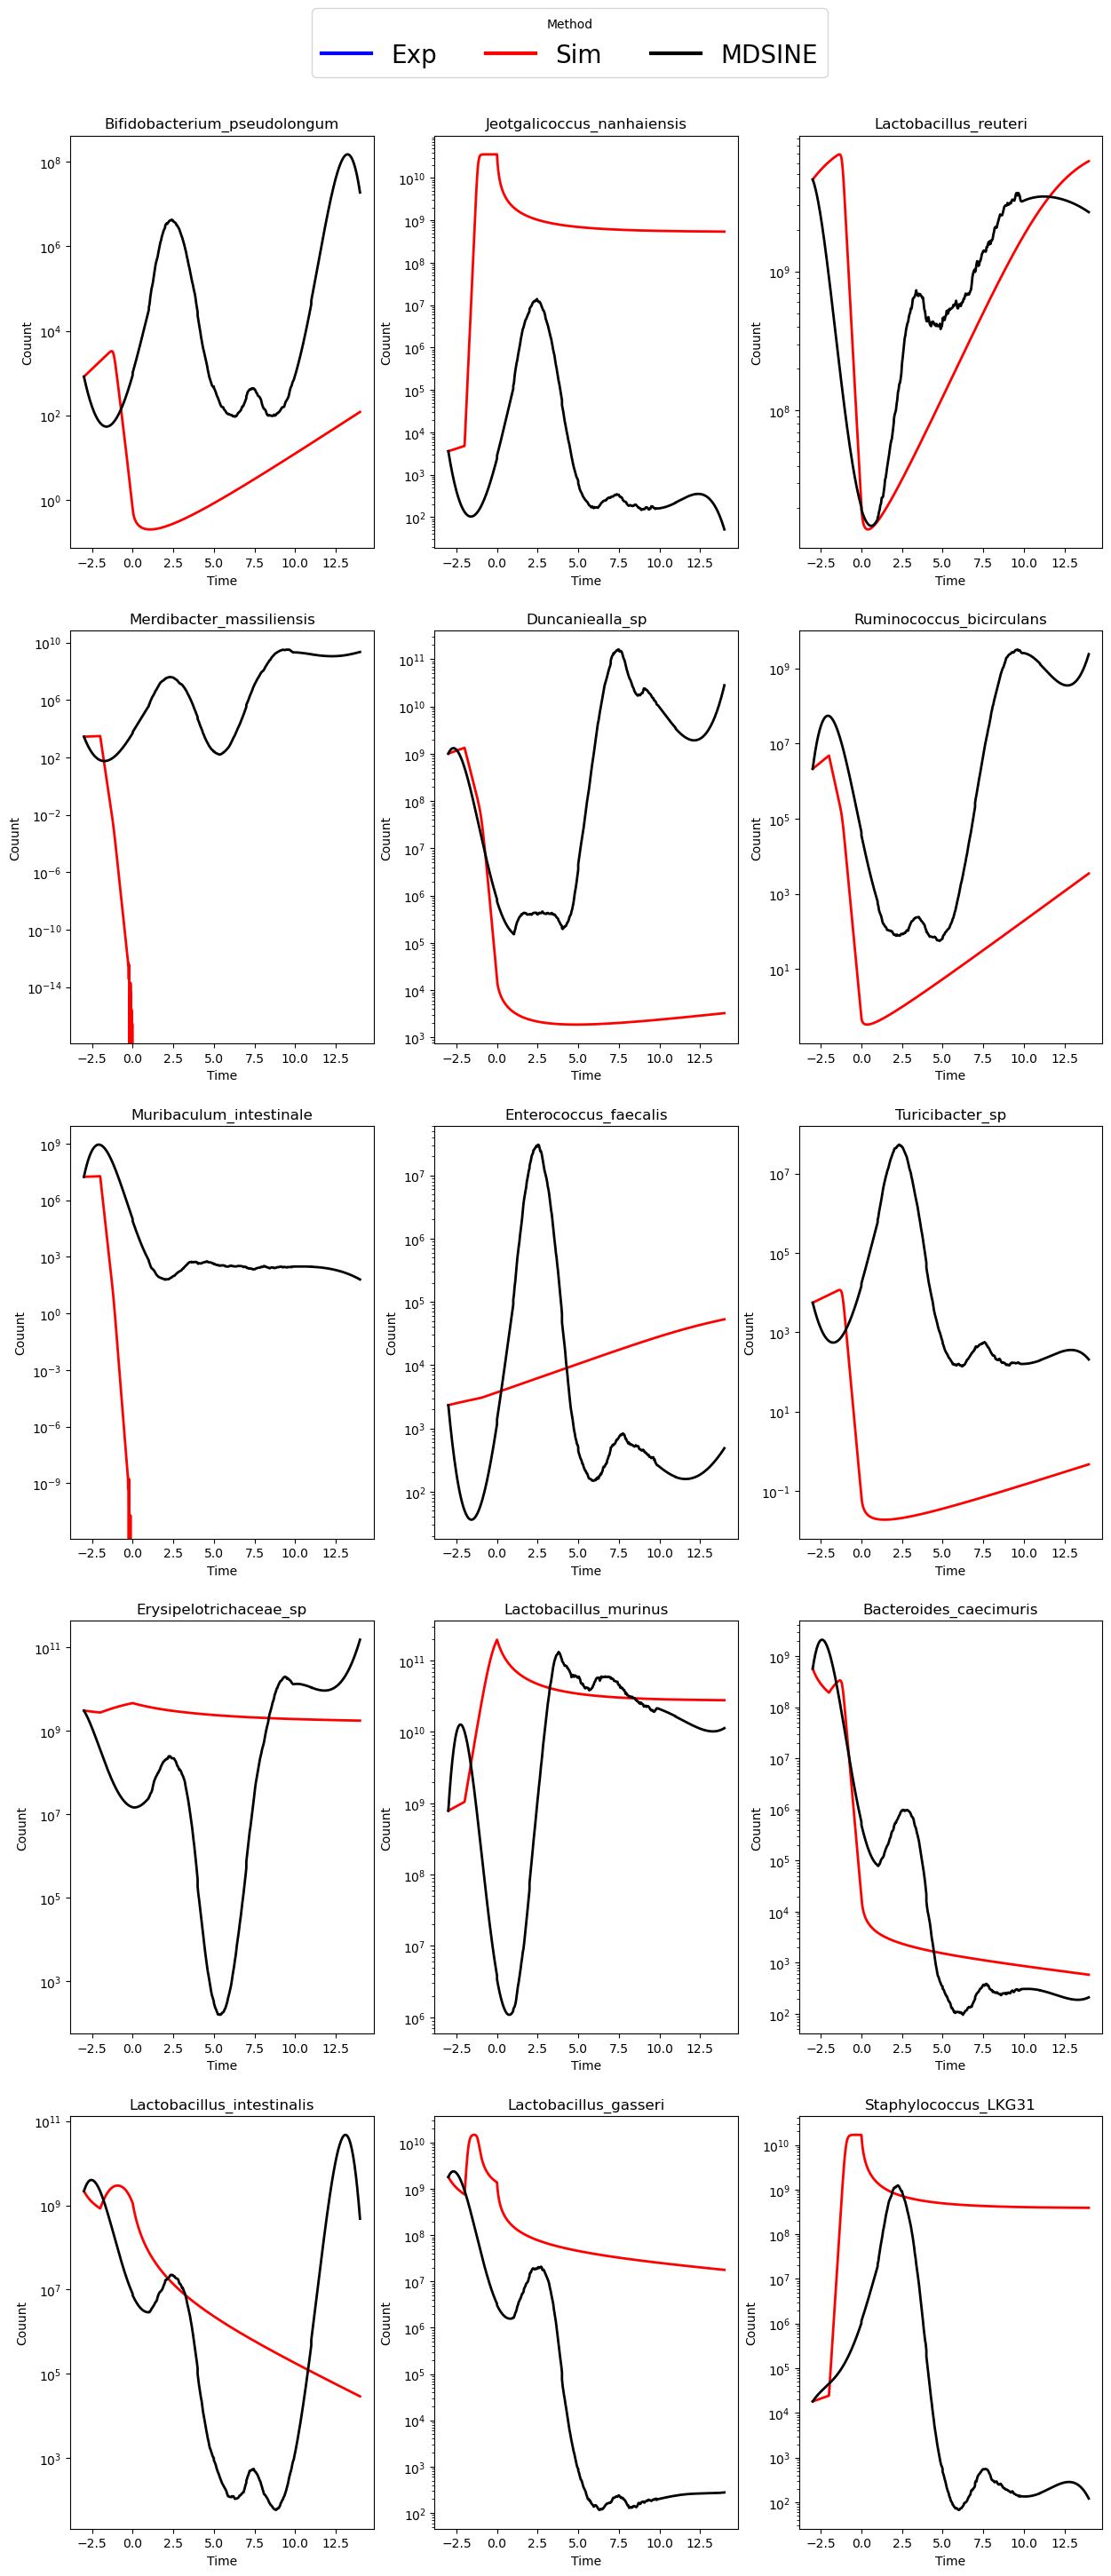

In [26]:
num_plots = 15
cols = 3  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, species in enumerate(asv_to_agora_dict.keys()):
    print(species)
    temp_sim = sol_odeint_df[sol_odeint_df['species'] == species]
    #temp_exp = testing_melt_abs_abun_plotting[testing_melt_abs_abun_plotting['species'] == species]
    temp_mdsine = MDSINE_output[MDSINE_output['species'] == species]
        # Scatter plot on the respective subplot
    
    #sns.lineplot(ax = axes[i], x = temp_exp['time'], y = temp_exp['count'], c = 'blue', lw = 2)
    sns.lineplot(ax=axes[i], x=temp_sim['time'], y=temp_sim['count'], c = 'red', lw =2)
    sns.lineplot(ax=axes[i], x=temp_mdsine['time'], y=temp_mdsine['count'], c = 'black', lw =2)
    
    species = asv_to_agora_dict[species]
    axes[i].set_title(f"{species}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Couunt')
    axes[i].set_yscale('log')
    
    

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Create color legend (data sources)
color_legend_elements = [
    Line2D([0], [0], color='blue', lw=3, label='Exp'),
    Line2D([0], [0], color='red', lw=3, label='Sim'),
    Line2D([0], [0], color='black', lw=3, label='MDSINE')
]


# Add both legends below the plots
color_legend = fig.legend(handles=color_legend_elements, loc='upper center', 
                          bbox_to_anchor=(.5, .925), ncol=3, fontsize=20, title="Method")
#axs.legend(['Mean EB Abun', 'EB 95% CI', 'Mean PC Abun', 'PC 95% CI', 'EB Data', 'PC Data'])
#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_smoothed_predictions' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")

In [27]:
MDSINE_output_raw.sum(axis=0)

-3.0                   1.395811e+10
-2.9583333333333335    1.452974e+10
-2.916666666666667     1.516579e+10
-2.8750000000000004    1.586819e+10
-2.833333333333334     1.663530e+10
                           ...     
13.833333333333272     1.293755e+11
13.87499999999994      1.423923e+11
13.916666666666607     1.578138e+11
13.958333333333272     1.759931e+11
14.0                   1.973726e+11
Length: 416, dtype: float64

In [28]:
MDSINE_output_raw_RA = MDSINE_output_raw/MDSINE_output_raw.sum(axis=0)
MDSINE_output_raw_RA

,-3.0,-2.9583333333333335,-2.916666666666667,-2.8750000000000004,-2.833333333333334,-2.7916666666666674,-2.750000000000001,-2.7083333333333344,-2.666666666666668,-2.6250000000000013,...,13.62499999999994,13.666666666666607,13.708333333333275,13.74999999999994,13.791666666666607,13.833333333333272,13.87499999999994,13.916666666666607,13.958333333333272,14.0
14ac4eaad5b4e2ff3c071832e0fd4229,5.892110e-08,4.789816e-08,3.904797e-08,3.193171e-08,2.620571e-08,2.159815e-08,1.789210e-08,1.491312e-08,1.252029e-08,1.059955e-08,...,9.873497e-04,8.382984e-04,6.938649e-04,5.600743e-04,4.411500e-04,3.393291e-04,2.550695e-04,1.874773e-04,1.347919e-04,9.481909e-05
18673193aa6bf30c6a1e71ac504e04df,2.578332e-07,1.980745e-07,1.529832e-07,1.188153e-07,9.283158e-08,7.301064e-08,5.784913e-08,4.622133e-08,3.727997e-08,3.038514e-08,...,1.390516e-09,1.221443e-09,1.055929e-09,8.989009e-10,7.541995e-10,6.242950e-10,5.103163e-10,4.122822e-10,3.294111e-10,2.604196e-10
320dfd16200daaf2b0503975d4e68fd5,3.285094e-01,3.057944e-01,2.826774e-01,2.596117e-01,2.370353e-01,2.153438e-01,1.948665e-01,1.758501e-01,1.584536e-01,1.427512e-01,...,3.092572e-02,2.933403e-02,2.749599e-02,2.548644e-02,2.338399e-02,2.126063e-02,1.917543e-02,1.717244e-02,1.528156e-02,1.352083e-02
36173253c63ad49abc12361a0b3304eb,2.013914e-07,1.466343e-07,1.077176e-07,7.984472e-08,5.973908e-08,4.513990e-08,3.447227e-08,2.662967e-08,2.082890e-08,1.651208e-08,...,1.906119e-02,1.867895e-02,1.810103e-02,1.735757e-02,1.648644e-02,1.552691e-02,1.451495e-02,1.348075e-02,1.244799e-02,1.143433e-02
391821255f31ef94686927f4fba6fbc3,7.198495e-02,7.403762e-02,7.514232e-02,7.530011e-02,7.456496e-02,7.303678e-02,7.084911e-02,6.815408e-02,6.510722e-02,6.185469e-02,...,1.039960e-01,1.101114e-01,1.156721e-01,1.206503e-01,1.250792e-01,1.290336e-01,1.326087e-01,1.359020e-01,1.390021e-01,1.419832e-01
3936cc515320e9f29d81ffeaa92718e8,1.519175e-04,1.988235e-04,2.549156e-04,3.203925e-04,3.950992e-04,4.785625e-04,5.700721e-04,6.687897e-04,7.738644e-04,8.845319e-04,...,9.355542e-03,9.782994e-03,1.016268e-02,1.049595e-02,1.078912e-02,1.105163e-02,1.129413e-02,1.152710e-02,1.175996e-02,1.200078e-02
3e741fc097143bb6782af5233cb7af98,1.258162e-03,1.774833e-03,2.440584e-03,3.274061e-03,4.289128e-03,5.493667e-03,6.889181e-03,8.471203e-03,1.023037e-02,1.215384e-02,...,1.011080e-09,9.285871e-10,8.421713e-10,7.547657e-10,6.690859e-10,5.873329e-10,5.110688e-10,4.412354e-10,3.782547e-10,3.221583e-10
4cc9a4b9aaa3ee9a5c14cc27551a6844,1.670227e-07,1.241640e-07,9.288383e-08,6.993511e-08,5.302022e-08,4.049958e-08,3.119422e-08,2.425080e-08,1.904836e-08,1.513326e-08,...,3.854563e-09,3.803632e-09,3.711639e-09,3.584015e-09,3.427955e-09,3.251143e-09,3.060781e-09,2.863037e-09,2.662849e-09,2.463988e-09
795b6ba45f502a00b24b212278991c63,3.968509e-07,3.262236e-07,2.689683e-07,2.224822e-07,1.847150e-07,1.540339e-07,1.291259e-07,1.089256e-07,9.256361e-08,7.932878e-08,...,3.128886e-09,2.903798e-09,2.657777e-09,2.400589e-09,2.141741e-09,1.889377e-09,1.649721e-09,1.427000e-09,1.223666e-09,1.040766e-09
7ca7ca8214441730c2437d1f53390cdb,2.158241e-01,1.944529e-01,1.741102e-01,1.550002e-01,1.372884e-01,1.210917e-01,1.064727e-01,9.343972e-02,8.195131e-02,7.192585e-02,...,5.985662e-01,6.307150e-01,6.589122e-01,6.829797e-01,7.031000e-01,7.196960e-01,7.333013e-01,7.444565e-01,7.536420e-01,7.612481e-01


In [30]:
sim_raw = pd.DataFrame(sol_odeint, columns = MDSINE_output_raw.index).T
sim_RA = sim_raw/sim_raw.sum(axis=0)
sim_RA


,0,1,2,3,4,5,6,7,8,9,...,4150,4151,4152,4153,4154,4155,4156,4157,4158,4159
14ac4eaad5b4e2ff3c071832e0fd4229,5.892110e-08,5.922464e-08,5.952806e-08,5.983138e-08,6.013461e-08,6.043776e-08,6.074085e-08,6.104388e-08,6.134686e-08,6.164981e-08,...,3.203852e-09,3.211073e-09,3.218312e-09,3.225567e-09,3.232839e-09,3.240128e-09,3.247433e-09,3.254756e-09,3.262095e-09,3.269452e-09
18673193aa6bf30c6a1e71ac504e04df,2.578332e-07,2.585667e-07,2.592949e-07,2.600180e-07,2.607360e-07,2.614491e-07,2.621572e-07,2.628604e-07,2.635588e-07,2.642525e-07,...,1.477360e-02,1.477200e-02,1.477040e-02,1.476880e-02,1.476721e-02,1.476562e-02,1.476403e-02,1.476244e-02,1.476086e-02,1.475927e-02
320dfd16200daaf2b0503975d4e68fd5,3.285094e-01,3.295284e-01,3.305406e-01,3.315461e-01,3.325451e-01,3.335374e-01,3.345233e-01,3.355029e-01,3.364761e-01,3.374431e-01,...,1.681863e-01,1.682756e-01,1.683648e-01,1.684538e-01,1.685428e-01,1.686316e-01,1.687203e-01,1.688089e-01,1.688973e-01,1.689857e-01
36173253c63ad49abc12361a0b3304eb,2.013914e-07,2.018168e-07,2.022373e-07,2.026531e-07,2.030643e-07,2.034709e-07,2.038729e-07,2.042704e-07,2.046636e-07,2.050523e-07,...,-4.486973e-28,-4.486633e-28,-4.486294e-28,-4.485956e-28,-4.485618e-28,-4.485281e-28,-4.484945e-28,-4.484608e-28,-4.484273e-28,-4.483938e-28
391821255f31ef94686927f4fba6fbc3,7.198495e-02,7.219391e-02,7.240139e-02,7.260742e-02,7.281202e-02,7.301520e-02,7.321699e-02,7.341740e-02,7.361645e-02,7.381416e-02,...,8.889065e-08,8.891319e-08,8.893576e-08,8.895834e-08,8.898094e-08,8.900355e-08,8.902619e-08,8.904884e-08,8.907151e-08,8.909420e-08
3936cc515320e9f29d81ffeaa92718e8,1.519175e-04,1.526803e-04,1.534426e-04,1.542045e-04,1.549659e-04,1.557269e-04,1.564876e-04,1.572479e-04,1.580079e-04,1.587677e-04,...,9.227127e-08,9.253755e-08,9.280461e-08,9.307244e-08,9.334106e-08,9.361047e-08,9.388067e-08,9.415165e-08,9.442344e-08,9.469601e-08
3e741fc097143bb6782af5233cb7af98,1.258162e-03,1.260671e-03,1.263148e-03,1.265595e-03,1.268012e-03,1.270400e-03,1.272758e-03,1.275087e-03,1.277387e-03,1.279660e-03,...,-1.727145e-23,-1.726673e-23,-1.726201e-23,-1.725729e-23,-1.725257e-23,-1.724785e-23,-1.724313e-23,-1.723841e-23,-1.723369e-23,-1.722897e-23
4cc9a4b9aaa3ee9a5c14cc27551a6844,1.670227e-07,1.674031e-07,1.677796e-07,1.681522e-07,1.685210e-07,1.688861e-07,1.692474e-07,1.696051e-07,1.699592e-07,1.703097e-07,...,1.436051e-06,1.436673e-06,1.437295e-06,1.437917e-06,1.438539e-06,1.439162e-06,1.439785e-06,1.440408e-06,1.441031e-06,1.441654e-06
795b6ba45f502a00b24b212278991c63,3.968509e-07,3.982626e-07,3.996681e-07,4.010674e-07,4.024607e-07,4.038481e-07,4.052296e-07,4.066053e-07,4.079754e-07,4.093398e-07,...,1.257318e-11,1.258745e-11,1.260173e-11,1.261602e-11,1.263034e-11,1.264467e-11,1.265902e-11,1.267339e-11,1.268778e-11,1.270219e-11
7ca7ca8214441730c2437d1f53390cdb,2.158241e-01,2.160757e-01,2.163215e-01,2.165618e-01,2.167966e-01,2.170259e-01,2.172499e-01,2.174686e-01,2.176821e-01,2.178906e-01,...,4.716870e-02,4.716161e-02,4.715452e-02,4.714744e-02,4.714038e-02,4.713332e-02,4.712626e-02,4.711922e-02,4.711218e-02,4.710516e-02


In [33]:
MDSINE_output_raw_RA_melt = MDSINE_output_raw_RA.melt(ignore_index=False).reset_index()
MDSINE_output_raw_RA_melt.columns = ['species','time', 'count']

sim_RA_melt = sim_RA.melt(ignore_index=False).reset_index()
sim_RA_melt.columns = ['species','time', 'count']

sim_RA_melt['time'] = (sim_RA_melt['time']/240)-3.0
sim_RA_melt

,species,time,count
0,14ac4eaad5b4e2ff3c071832e0fd4229,-3.000000,5.892110e-08
1,18673193aa6bf30c6a1e71ac504e04df,-3.000000,2.578332e-07
2,320dfd16200daaf2b0503975d4e68fd5,-3.000000,3.285094e-01
3,36173253c63ad49abc12361a0b3304eb,-3.000000,2.013914e-07
4,391821255f31ef94686927f4fba6fbc3,-3.000000,7.198495e-02
...,...,...,...
62395,94e30534f622e456a683abe4e60fc214,14.329167,7.580107e-01
62396,9cf5cb71450a2aa080ff905f89b0a624,14.329167,1.589478e-08
62397,e3147edad1f84fae8bb6fd6f5e7a97b9,14.329167,7.834180e-07
62398,e8aae590cf49eb3c80ad7e08f2d3c3c4,14.329167,4.854955e-04


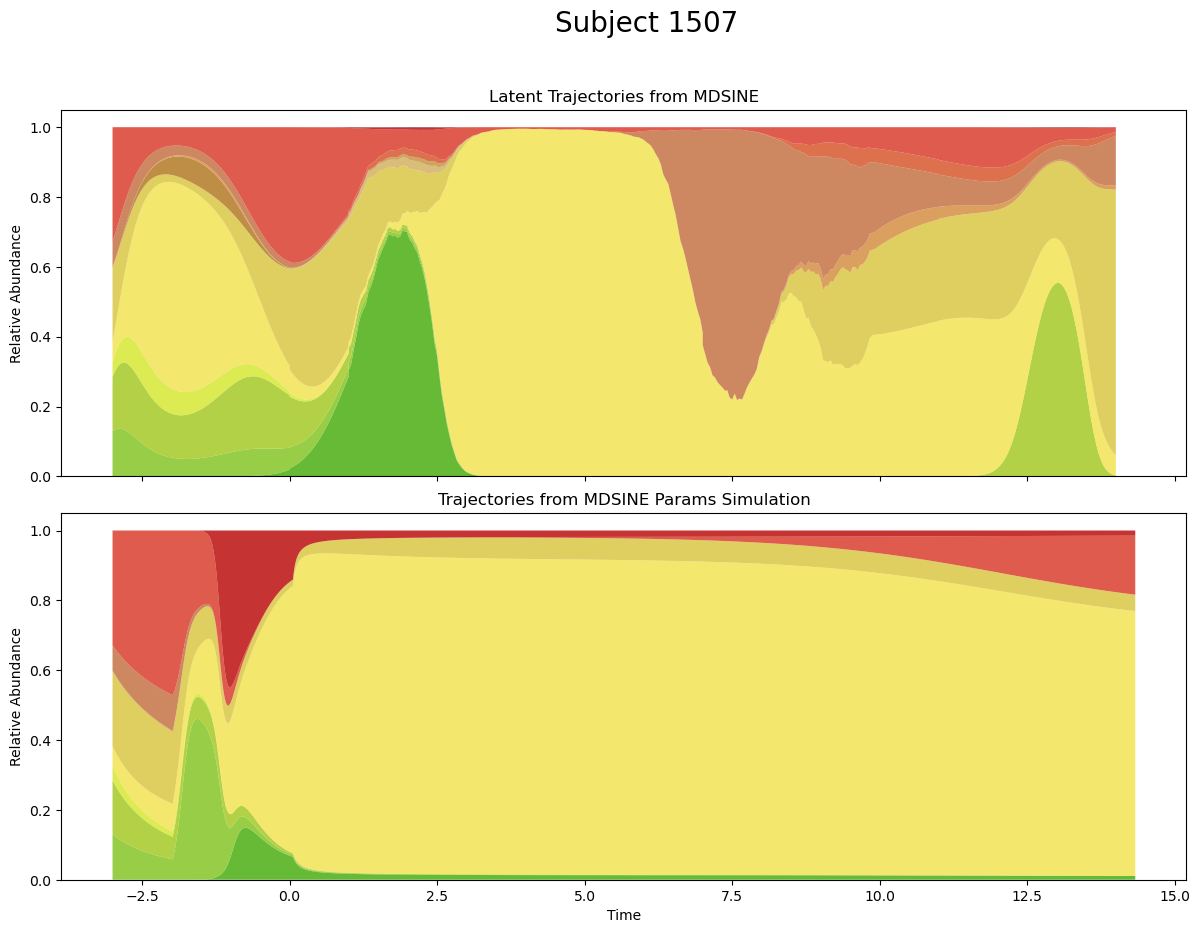

In [50]:
fig, (ax_middle, ax_bottom) = plt.subplots(
2, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]}
)

# Ensure time is numeric
MDSINE_output_raw_RA_melt['time'] = pd.to_numeric(MDSINE_output_raw_RA_melt['time'])
sim_RA_melt['time'] = pd.to_numeric(sim_RA_melt['time'])

# Define stacking order
feature_order = MDSINE_output_raw_RA_melt['species'].value_counts().index.tolist()
reversed_order = feature_order[::-1]  # For stackplot

# Assign consistent colors


twentysiz = [
    "#690f19", "#b80000", "#d63220", "#d64e20", "#c1693a",  # reds/oranges
    "#d38838", "#AE7219", "#C09038", "#d1ad57", "#d8c33a", "#f1e149",  # orange/yellows
    "#d2e626", "#a0c618", "#7dc119", "#40a903", "#0c9515",  # yellow/green
    "#1da05a", "#1da18d", "#1d91a1", "#1d6ea1", "#1d31a1",  # green/blue
    "#1a1a87", "#5b5bc9", "#8d8df1", "#8670cc", "#9870cc",  # blue/purple
    "#000000"  # black
]
#sns.set_style("dark")  # or "whitegrid", "dark", etc.
#sns.set_context("notebook")  # or "paper", "talk", "poster"
sns.set_palette(twentysiz)

#palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, twentysiz))

# Pivot for stackplot in reversed stacking order
continuous_pivot_MDSINE = (
    MDSINE_output_raw_RA_melt
    .pivot(index='time', columns='species', values='count')
    .fillna(0)
)[reversed_order]

# Pivot for stackplot in reversed stacking order
continuous_pivot_sim = (
    sim_RA_melt
    .pivot(index='time', columns='species', values='count')
    .fillna(0)
)[reversed_order]



# Middle: stackplot using reversed order and matching colors
ax_middle.stackplot(
    continuous_pivot_MDSINE.index,
    *[continuous_pivot_MDSINE[col] for col in continuous_pivot_MDSINE.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_middle.set_ylabel('Relative Abundance')
#ax_middle.set_xlabel('Time')
ax_middle.set_title('Latent Trajectories from MDSINE')

# Bottom: stackplot using FBA output 

# Bottom: stackplot using reversed order and matching colors
ax_bottom.stackplot(
    continuous_pivot_sim.index,
    *[continuous_pivot_sim[col] for col in continuous_pivot_sim.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_bottom.set_ylabel('Relative Abundance')
ax_bottom.set_xlabel('Time')
ax_bottom.set_title('Trajectories from MDSINE Params Simulation')



# Tidy layout
#ax_top.tick_params(labelbottom=False)
plt.subplots_adjust(hspace=0.1, right=0.75)


# Create custom legend handles using your color map
#legend_elements = [
#    Patch(facecolor=color_map[feat], label=ASV_string_to_species_names_dict[feat])
#    for feat in feature_order
#]

# Add custom legend to the *figure* (not either axis), outside plot
#fig.legend(
#    handles=legend_elements,
#    title='Species',
#    loc='center left',
#    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
 #   borderaxespad=0,
#    frameon=False,
#    ncol=1
#)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=0.1, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.45, fontsize = 20)
plt.subplots_adjust(right=0.75)
#second_plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_stacked_hist_line_plots_FBA_' + str(test_num) + '.pdf'
#plt.savefig(second_plot_file_name, bbox_inches="tight")
plt.show()
#plt.close()


In [35]:
MDSINE_output_raw_total_abun = MDSINE_output_raw.sum(axis=0).reset_index()
MDSINE_output_raw_total_abun.columns = ['time', 'total_abundance']

In [36]:
MDSINE_output_raw_total_abun['time'] = MDSINE_output_raw_total_abun['time'].astype(float)

In [37]:
sim_total_abun=pd.DataFrame(sol_odeint).sum(axis=1).reset_index()
sim_total_abun.columns = ['time', 'total_abundance']

In [38]:
sim_total_abun['time'] = (sim_total_abun['time']/240)-3.0

In [39]:
MDSINE_output_raw_total_abun

,time,total_abundance
0,-3.000000,1.395811e+10
1,-2.958333,1.452974e+10
2,-2.916667,1.516579e+10
3,-2.875000,1.586819e+10
4,-2.833333,1.663530e+10
...,...,...
411,13.833333,1.293755e+11
412,13.875000,1.423923e+11
413,13.916667,1.578138e+11
414,13.958333,1.759931e+11


In [40]:
sim_total_abun

,time,total_abundance
0,-3.000000,1.395811e+10
1,-2.995833,1.393481e+10
2,-2.991667,1.391195e+10
3,-2.987500,1.388952e+10
4,-2.983333,1.386749e+10
...,...,...
4155,14.312500,3.674871e+10
4156,14.316667,3.675188e+10
4157,14.320833,3.675505e+10
4158,14.325000,3.675821e+10


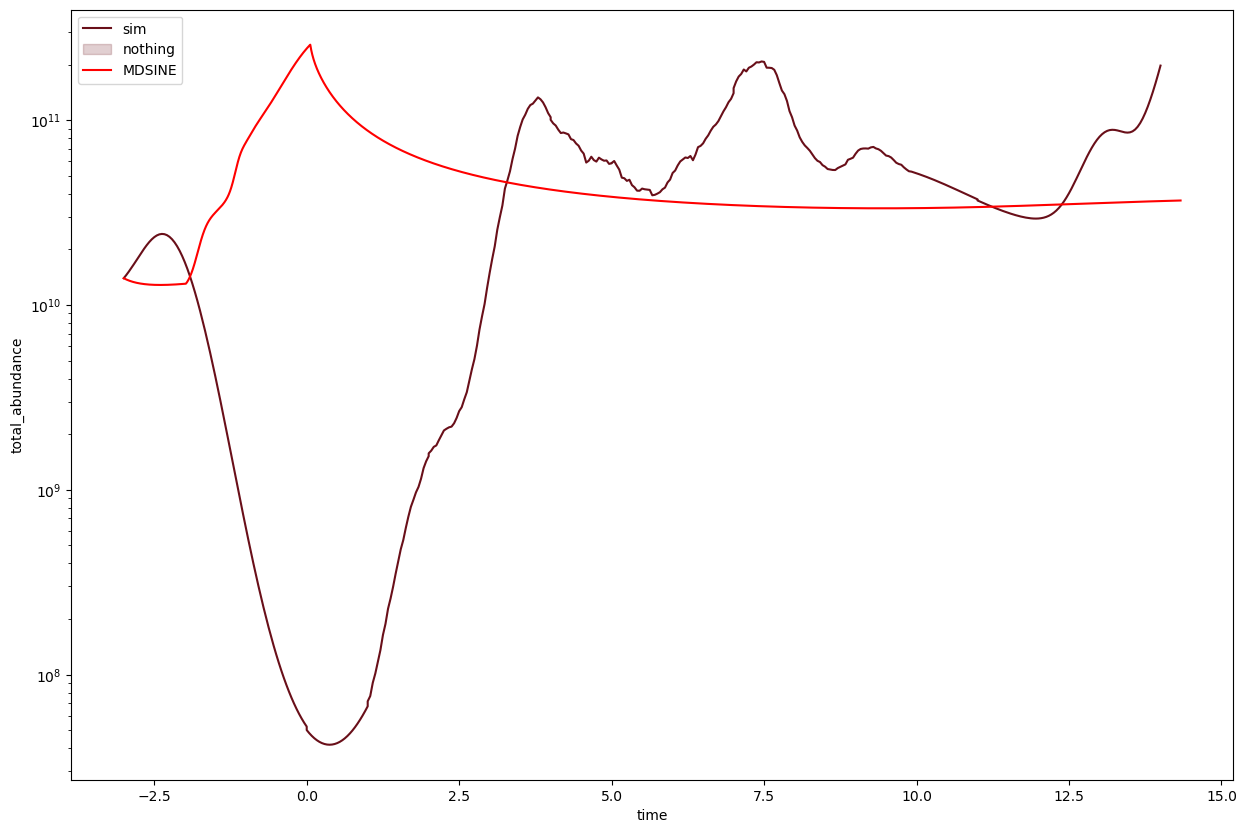

In [41]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=MDSINE_output_raw_total_abun, x='time', y='total_abundance')
sns.lineplot(data=sim_total_abun, x='time', y='total_abundance', color = 'red')
plt.legend(['sim', 'nothing', 'MDSINE'])
plt.yscale('log')

In [42]:
MDSINE_output_raw_total_abun

,time,total_abundance
0,-3.000000,1.395811e+10
1,-2.958333,1.452974e+10
2,-2.916667,1.516579e+10
3,-2.875000,1.586819e+10
4,-2.833333,1.663530e+10
...,...,...
411,13.833333,1.293755e+11
412,13.875000,1.423923e+11
413,13.916667,1.578138e+11
414,13.958333,1.759931e+11


In [43]:
def forward_euler_glv(
    glv_func,
    t0,
    tf,
    dt,
    init_abun,
    int_matrix,
    basal_grow,
    perturbations
):
    """
    Forward Euler integration for gLV with perturbations.

    Args:
        glv_func (callable): gLV function (e.g., gLV_perturb)
        t0 (float): initial time
        tf (float): final time
        dt (float): time step
        init_abun (array): initial abundances (n_species,)
        int_matrix (2D array): interaction matrix (n_species, n_species)
        basal_grow (array): basal growth rates (n_species,)
        perturbations (array): perturbation magnitudes (n_species,)

    Returns:
        t (array): time points
        X (2D array): abundances over time (n_timepoints, n_species)
    """
    t = np.arange(t0, tf + dt, dt)
    n_steps = len(t)
    n_species = len(init_abun)

    X = np.zeros((n_steps, n_species))
    int_matrix_eff = np.zeros((n_steps, n_species))
    X[0, :] = init_abun

    for i in range(n_steps - 1):
        dXdt = glv_func(
            t[i],
            X[i, :],
            int_matrix,
            basal_grow,
            perturbations
        )
        X[i + 1, :] = X[i, :] + dt * dXdt
        int_matrix_eff[i+1,:] = np.dot(int_matrix, X[i, :])

        # optional: prevent negative abundances
        X[i + 1, :] = np.maximum(X[i + 1, :], 1e4)
        
        

    return t, X, int_matrix_eff


In [44]:
int_array, growth_array, perturb_array

(array([[-8.47700426e-11, -2.16062410e-10,  0.00000000e+00,
         -1.04854015e-10,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -5.87852273e-12,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -5.37454043e-10,  0.00000000e+00,
         -4.18480078e-10,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -1.96985775e-11,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -1.55015365e-10, -7.15871688e-11,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -1.93249275e-10,  0.00000000e+00,
         -2.51827532e-10,  0.00000000

In [45]:
t, X, int_matrix_eff = forward_euler_glv(
    gLV_perturb,
    t0=0.0,
    tf=17.0,
    dt=1/24,
    init_abun=init_abun,
    int_matrix=int_array,
    basal_grow=growth_array,
    perturbations=perturb_array
)


perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation
perturbation


In [58]:
metabolomics_data = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/complete_mapping_metabolomics.csv', index_col=0)
rc_diet_data = metabolomics_data[metabolomics_data['SampleName'] == 'RC_001']
rc_diet_data = rc_diet_data.fillna(0)
rc_diet_data = rc_diet_data.T

In [61]:
rc_diet_data

,68
SampleName,RC_001
12_Ketolithocholic acid,0.0
drib,0.0
5oxpro,0.131
ala__L,0.836
...,...
akg,0.0
cis_Oleic acid,3.842
meso_Erythritol,0.064
inost,0.502


In [46]:
forward_euler_odeint_df = pd.DataFrame(X, columns = MDSINE_output_raw.index, index = t)
forward_euler_odeint_df = forward_euler_odeint_df.melt(ignore_index=False).reset_index()
forward_euler_odeint_df.columns = ['time','species', 'count']
forward_euler_odeint_df['time'] = forward_euler_odeint_df['time'] - 3.0

forward_euler_odeint_df

,time,species,count
0,-3.000000,14ac4eaad5b4e2ff3c071832e0fd4229,8.224269e+02
1,-2.958333,14ac4eaad5b4e2ff3c071832e0fd4229,1.000000e+04
2,-2.916667,14ac4eaad5b4e2ff3c071832e0fd4229,1.035353e+04
3,-2.875000,14ac4eaad5b4e2ff3c071832e0fd4229,1.071953e+04
4,-2.833333,14ac4eaad5b4e2ff3c071832e0fd4229,1.109845e+04
...,...,...,...
6145,13.875000,eba523a4a554db4ad7e9dcff257bf1c8,3.913104e+08
6146,13.916667,eba523a4a554db4ad7e9dcff257bf1c8,3.912402e+08
6147,13.958333,eba523a4a554db4ad7e9dcff257bf1c8,3.911710e+08
6148,14.000000,eba523a4a554db4ad7e9dcff257bf1c8,3.911026e+08


14ac4eaad5b4e2ff3c071832e0fd4229
18673193aa6bf30c6a1e71ac504e04df
320dfd16200daaf2b0503975d4e68fd5
36173253c63ad49abc12361a0b3304eb
391821255f31ef94686927f4fba6fbc3
3936cc515320e9f29d81ffeaa92718e8
3e741fc097143bb6782af5233cb7af98
4cc9a4b9aaa3ee9a5c14cc27551a6844
795b6ba45f502a00b24b212278991c63
7ca7ca8214441730c2437d1f53390cdb
94e30534f622e456a683abe4e60fc214
9cf5cb71450a2aa080ff905f89b0a624
e3147edad1f84fae8bb6fd6f5e7a97b9
e8aae590cf49eb3c80ad7e08f2d3c3c4
eba523a4a554db4ad7e9dcff257bf1c8


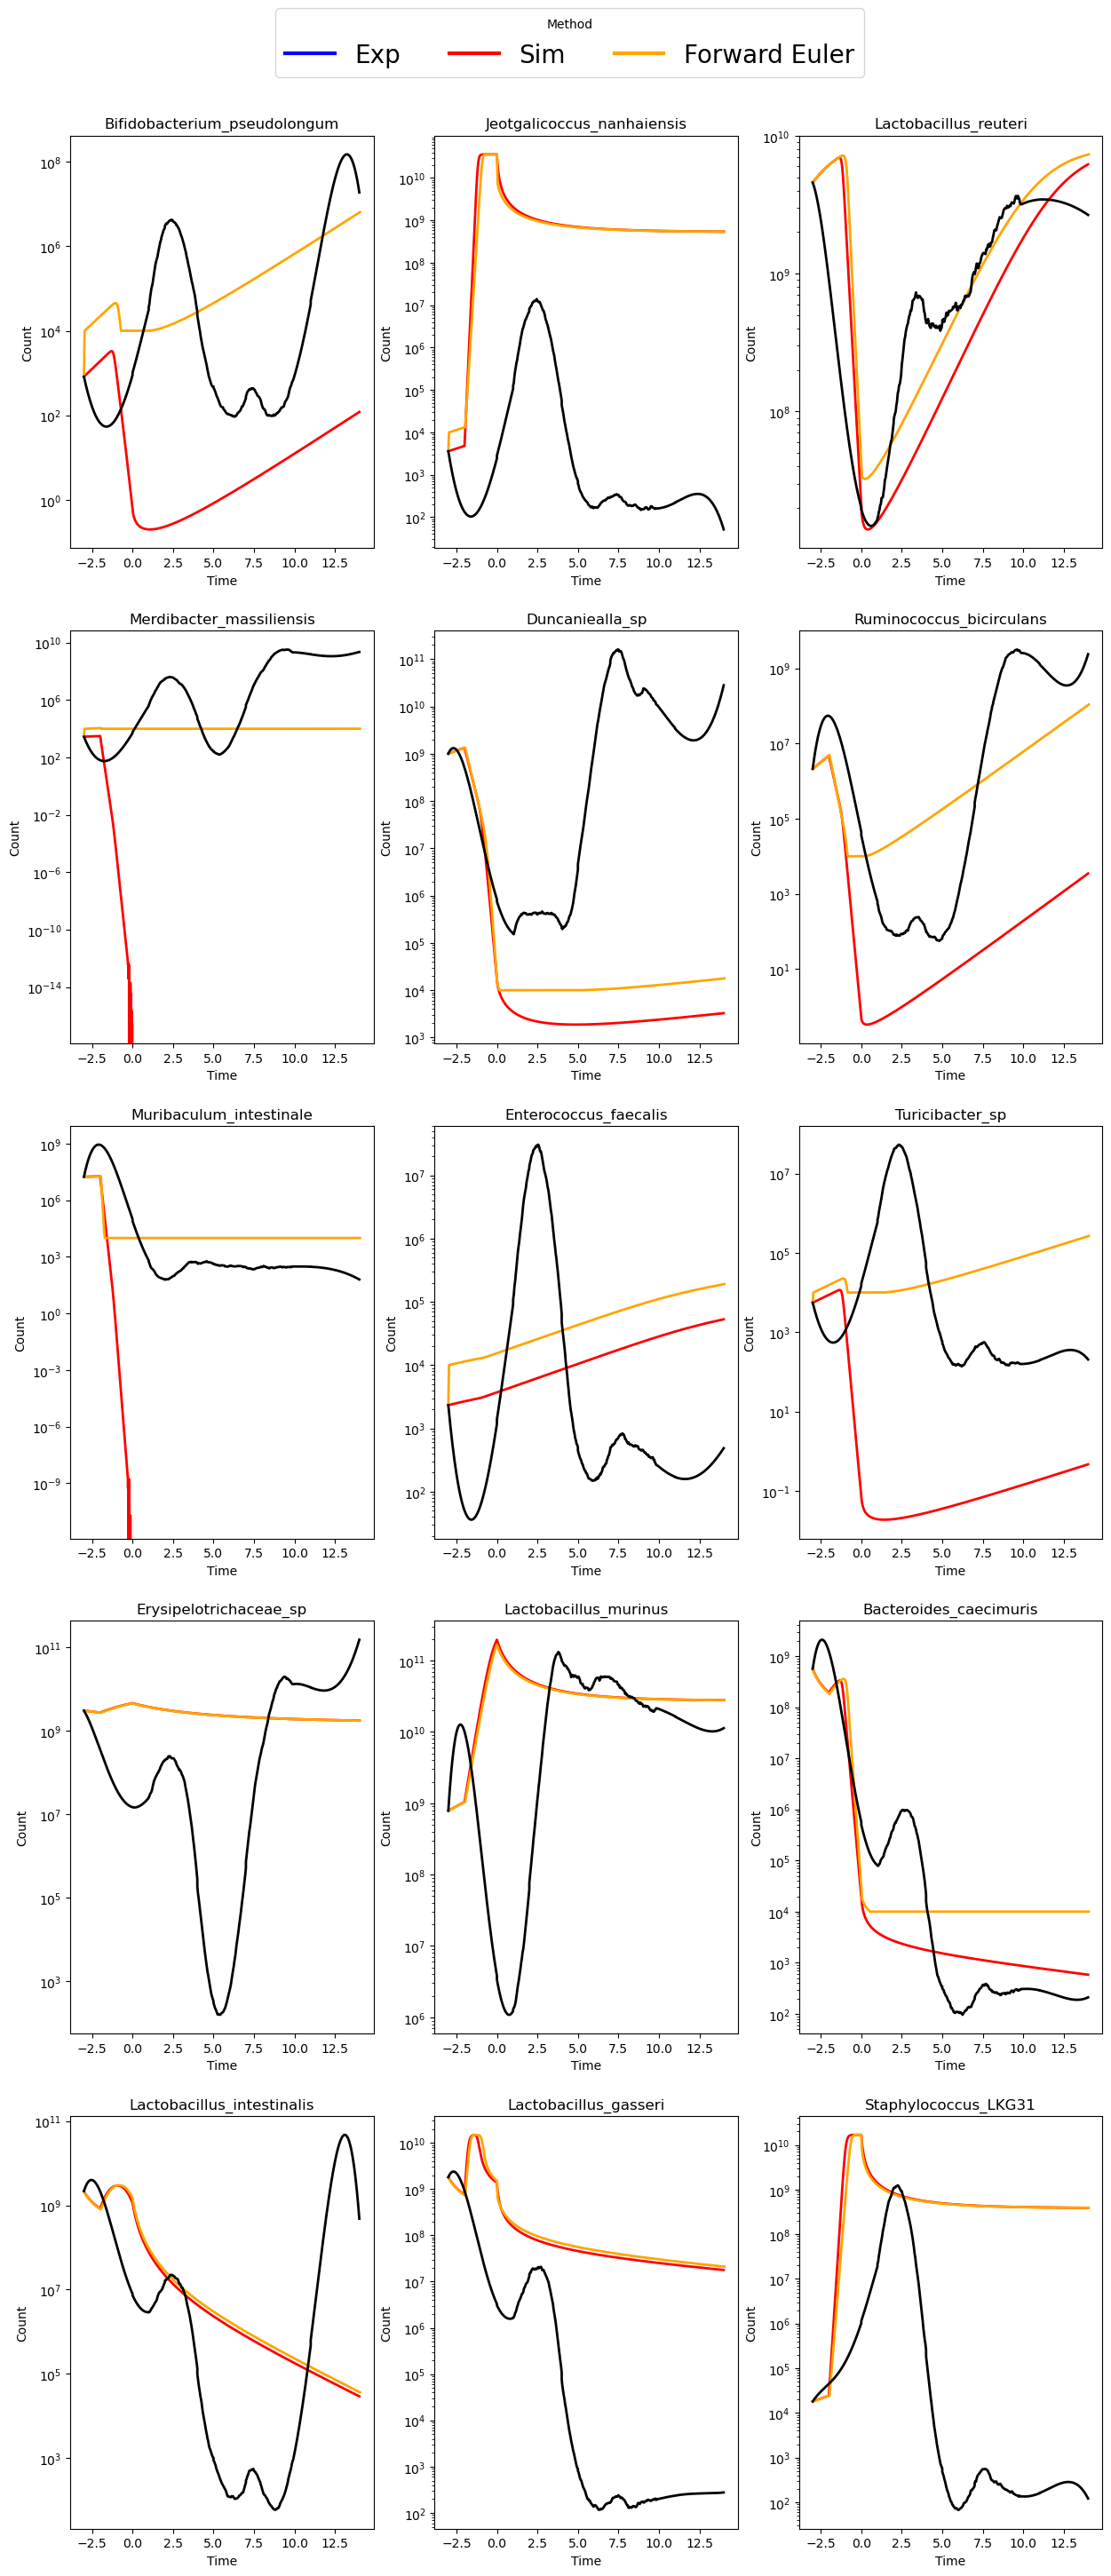

In [47]:
num_plots = 15
cols = 3  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, species in enumerate(asv_to_agora_dict.keys()):
    print(species)
    temp_sim = sol_odeint_df[sol_odeint_df['species'] == species]
    temp_for = forward_euler_odeint_df[forward_euler_odeint_df['species'] == species]
    temp_mdsine = MDSINE_output[MDSINE_output['species'] == species]
        # Scatter plot on the respective subplot
    
    #sns.lineplot(ax = axes[i], x = temp_exp['time'], y = temp_exp['count'], c = 'blue', lw = 2)
    sns.lineplot(ax=axes[i], x=temp_sim['time'], y=temp_sim['count'], c = 'red', lw =2)
    sns.lineplot(ax=axes[i], x=temp_for['time'], y=temp_for['count'], c = 'orange', lw =2)
    sns.lineplot(ax=axes[i], x=temp_mdsine['time'], y=temp_mdsine['count'], c = 'black', lw =2)
    
    species = asv_to_agora_dict[species]
    axes[i].set_title(f"{species}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Count')
    axes[i].set_yscale('log')
    
    

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Create color legend (data sources)
color_legend_elements = [
    Line2D([0], [0], color='blue', lw=3, label='Exp'),
    Line2D([0], [0], color='red', lw=3, label='Sim'),
    Line2D([0], [0], color='orange', lw=3, label='Forward Euler'),
]


# Add both legends below the plots
color_legend = fig.legend(handles=color_legend_elements, loc='upper center', 
                          bbox_to_anchor=(.5, .925), ncol=3, fontsize=20, title="Method")
#axs.legend(['Mean EB Abun', 'EB 95% CI', 'Mean PC Abun', 'PC 95% CI', 'EB Data', 'PC Data'])
#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_smoothed_predictions' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")